Measure how often recalls move from a newly revisited repeated item to the neighbours of its earlier presentation. The `min_lag` filter enforces spaced repetitions, and the resulting curve highlights backward spread relative to the full forward/backward profile charted in `repcrp`.

Adjust `ctrl_query` to define alternative control populations.

Modify `min_lag` if you need to tighten or relax the spacing filter.

In [1]:
import os

import matplotlib.pyplot as plt

from jaxcmr.analyses.backrepcrp import (
    plot_back_rep_crp,
    subject_back_rep_crp,
    test_back_rep_crp_vs_control,
    test_first_second_bias,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset

In [2]:
data_name = "LohnasKahana2014"
data_query = "data['list_type'] > 2"
ctrl_query = "data['list_type'] == 1"
min_lag = 4
max_lag = 5
size = 2

In [3]:
project_root = find_project_root()
data_path = os.path.join(project_root, 'data', f'{data_name}.h5')
data = load_data(data_path)
trial_mask = generate_trial_mask(data, data_query)
control_dataset = make_control_dataset(data, data_query, ctrl_query, 10)
control_mask = generate_trial_mask(control_dataset, data_query)


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


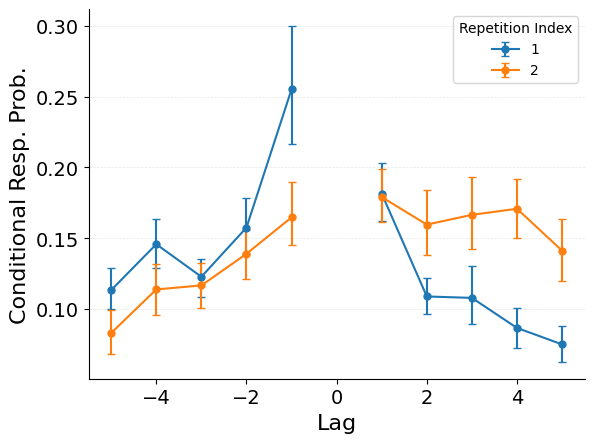

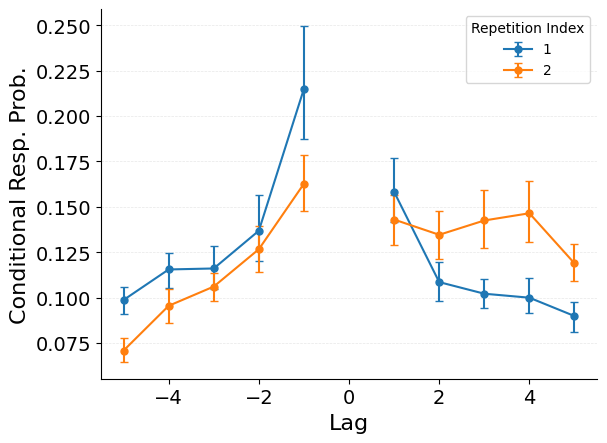

In [4]:
plot_back_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
plot_back_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
plt.show()

In [5]:
observed_crp = subject_back_rep_crp(data, trial_mask, min_lag, max_lag, size)
control_crp = subject_back_rep_crp(control_dataset, control_mask, min_lag, max_lag, size)

results = test_back_rep_crp_vs_control(observed_crp, control_crp, max_lag)
for label, result in results.items():
    print(f"\n{'='*60}")
    print(f"Statistical Tests: {label}")
    print(f"{'='*60}")
    print(result)


Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |    1.699     0.0984 |    222.0     0.1310 |     0.0147
   -4 |    3.327     0.0021 |    135.0     0.0025 |     0.0303
   -3 |    0.906     0.3715 |    241.0     0.2318 |     0.0067
   -2 |    2.255     0.0307 |    184.0     0.0313 |     0.0207
   -1 |    3.408     0.0017 |    133.0     0.0022 |     0.0402
    0 |      nan        nan |      nan        nan |        nan
    1 |    2.007     0.0528 |    212.0     0.0934 |     0.0232
    2 |    0.047     0.9630 |    313.0     0.9806 |     0.0003
    3 |    0.578     0.5672 |    297.0     0.7771 |     0.0057
    4 |   -1.316     0.1971 |    237.0     0.2071 |    -0.0133
    5 |   -2.011     0.0523 |    211.0     0.0902 |    -0.0148

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+------

/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:476: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_col, ctrl_col, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:487: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff)


In [6]:
bias_result = test_first_second_bias(observed_crp, control_crp, max_lag)
print(f"\n{'='*70}")
print("Test: First-Second Bias (Observed) vs First-Second Bias (Control)")
print(f"{'='*70}")
print("H0: The preference for first-presentation neighbors over second-presentation")
print("    neighbors is the same in observed data as in the shuffled control.")
print()
print(bias_result)


Test: First-Second Bias (Observed) vs First-Second Bias (Control)
H0: The preference for first-presentation neighbors over second-presentation
    neighbors is the same in observed data as in the shuffled control.

  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |    0.218     0.8286 |    312.0     0.9678 |     0.0025
   -4 |    0.970     0.3391 |    263.0     0.4036 |     0.0119
   -3 |   -0.390     0.6988 |    313.0     0.9806 |    -0.0039
   -2 |    0.738     0.4657 |    276.0     0.5329 |     0.0083
   -1 |    1.982     0.0556 |    188.0     0.0371 |     0.0382
    0 |      nan        nan |      nan        nan |        nan
    1 |   -1.019     0.3152 |    243.0     0.2449 |    -0.0129
    2 |   -1.785     0.0832 |    219.0     0.1187 |    -0.0247
    3 |   -1.445     0.1576 |    233.0     0.1843 |    -0.0183
    4 |   -2.677     0.0113 |    169.0     0.0158 |    -0.0377
    5 |   -2.849     0.00

/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:545: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_d, ctrl_d, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:556: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff_of_diff)
